### **SLP - Binary Classification Problem**
___

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
np.random.seed(42)

In [53]:
df = pd.read_csv('data.csv', header=None, names=['y', 'x1', 'x2'])
df.head()

,y,x1,x2
0,1,2.6487,4.5192
1,1,1.5438,2.4443
2,1,1.8990,4.2409
3,1,2.4711,5.8097
4,1,3.3590,6.4423


In [54]:
df.shape

(100, 3)

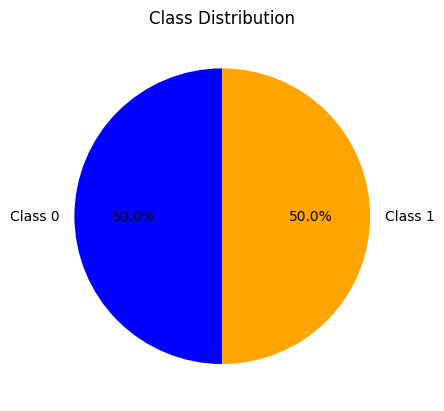

In [55]:
plt.Figure(figsize=(10, 6))
plt.pie(df['y'].value_counts(), labels=['Class 0', 'Class 1'], autopct='%1.1f%%', startangle=90, colors=['blue', 'orange'])
plt.title('Class Distribution')
plt.show()

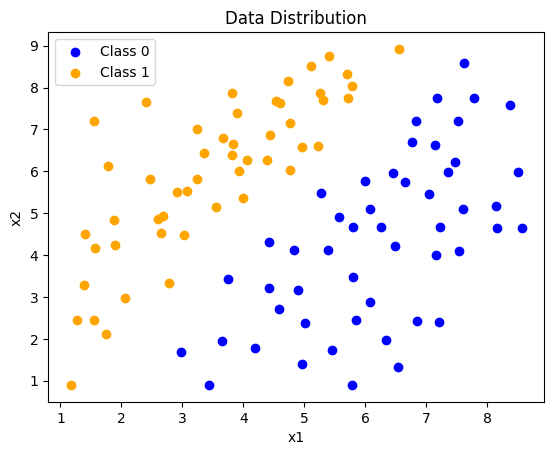

In [56]:
cls_0 = df[df['y'] == 0]
cls_1 = df[df['y'] == 1]
plt.Figure(figsize=(10, 6))
plt.scatter(cls_0['x1'], cls_0['x2'], color='blue', label='Class 0')
plt.scatter(cls_1['x1'], cls_1['x2'], color='orange', label='Class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data Distribution')
plt.legend()
plt.show()

In [57]:
x = df[['x1', 'x2']].values
y = df['y'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(80, 2) (80,)
(20, 2) (20,)


In [58]:
class SLP:
    def __init__(self, learning_rate=0.1, epochs=5, threshold=0.5):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.threshold = threshold
        self.weights = None

    def step_activation_func(self, net):
        if net >= self.threshold:
            return 1
        else:
            return 0

    def fit(self, x_train, y_train):
        # Add a bias column (all ones) to the training data
        x_train = np.append(np.ones((len(x_train), 1)), x_train, axis=1)
        
        # Initialize weights randomly with small values
        self.weights = np.random.randn(x_train.shape[1]) * 0.01 

        for epoch in range(self.epochs):
            for i in range(len(x_train)):
                net_input = np.dot(x_train[i], self.weights) #i is the index of the current training sample
                predicted = self.step_activation_func(net_input)
                
                # Update weights using the Perceptron learning rule
                error = y_train[i] - predicted
                self.weights += self.learning_rate * error * x_train[i]

            # Evaluate training accuracy
            y_pred_train = self.predict(x_train[:, 1:])  # Exclude bias column for prediction
            print(f"Epoch {epoch+1}, Accuracy: {accuracy_score(y_train, y_pred_train):.2f}") # Print accuracy after each epoch
            self.plot_decision_boundary(x_train[:, 1:], y_train)

    def predict(self, x):
        x = np.append(np.ones((len(x), 1)), x, axis=1)  # Add bias column again for prediction 
        net_input = np.dot(x, self.weights)
        predicted = np.array([self.step_activation_func(net) for net in net_input])
        return predicted
    
    def plot_decision_boundary(self, x, y):        
        # Generate a grid of points spanning the feature space
        X1, X2 = np.meshgrid(
            np.arange(x[:, 0].min() - 1, x[:, 0].max() + 1, step=0.02),
            np.arange(x[:, 1].min() - 1, x[:, 1].max() + 1, step=0.02)
        )
        
         # Predict class labels for each point in the grid
        Z = np.array(self.predict(np.c_[X1.ravel(), X2.ravel()])).reshape(X1.shape)
        
        # Plot the decision boundary using contour plot
        plt.contourf(X1, X2, Z, alpha=0.4, cmap=ListedColormap(['orange', 'blue']))
        plt.xlim(X1.min(), X1.max())
        plt.ylim(X2.min(), X2.max())

        # Overlay training data points
        for i, j in enumerate(np.unique(y)):
            plt.scatter(x[y == j, 0], x[y == j, 1], color=['orange', 'blue'][i], label=j)

        plt.title('Perceptron Decision Boundary')
        plt.xlabel('Feature x1')
        plt.ylabel('Feature x2')
        plt.legend()
        plt.show()

Epoch 1, Accuracy: 0.97


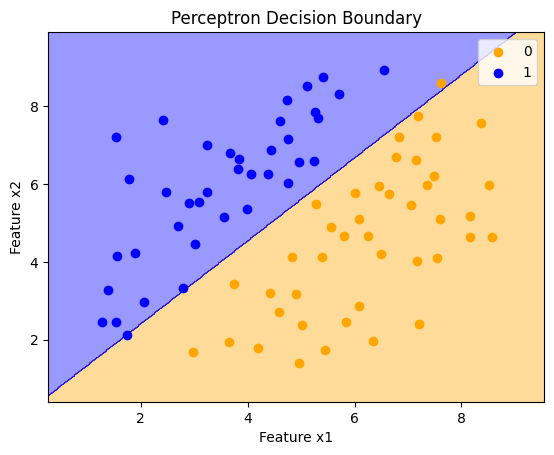

Epoch 2, Accuracy: 0.99


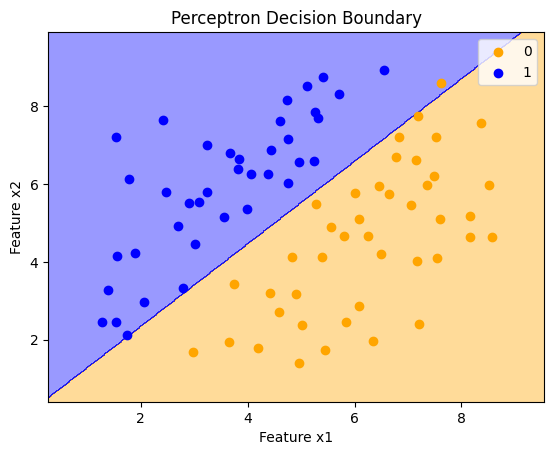

Epoch 3, Accuracy: 0.86


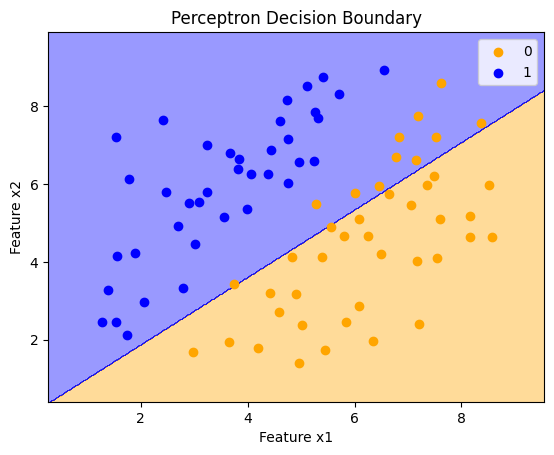

Epoch 4, Accuracy: 0.95


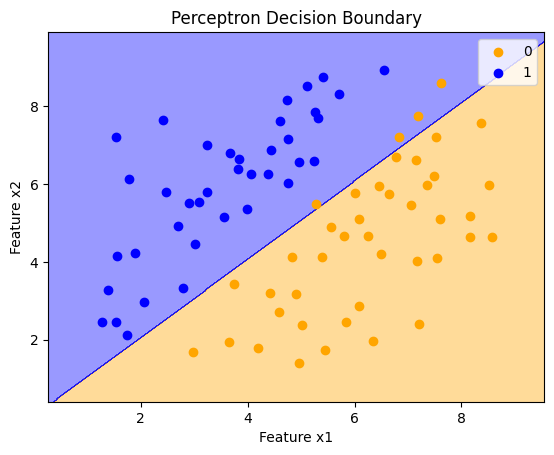

Epoch 5, Accuracy: 1.00


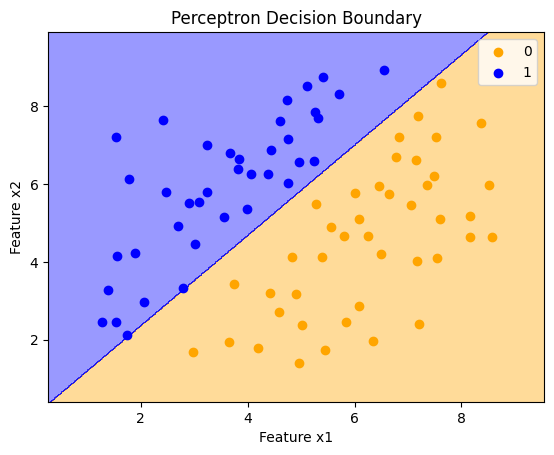

In [59]:
model = SLP()
model.fit(x_train, y_train)

### **Model Evaluation**
___

In [60]:
#Evaluate on test set
y_pred_test = model.predict(x_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_test) * 100:.2f}%")

Test Accuracy: 95.00%


In [63]:
# predicting on new data
new_data = np.array([[1.5, 1.5], [3.0, 2.6], [0, 0.5]])
predictions = model.predict(new_data)
print("Predictions for new data:", predictions)

Predictions for new data: [0 0 1]
